<a href="https://colab.research.google.com/github/LeonardoVS-dev/Fundamentos/blob/main/graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

dados_eleitorais = pd.read_csv("https://raw.githubusercontent.com/LeonardoVS-dev/Fundamentos/refs/heads/main/dataset/votacao_candidato_munzona_2024_RR%20LIMPADO_CORRIGIDO.csv", encoding="latin-1", sep=";")
dados_flight = pd.read_csv("https://raw.githubusercontent.com/LeonardoVS-dev/Fundamentos/refs/heads/main/dataset/flights.csv", sep=",")
display(dados_eleitorais)

<Axes: xlabel='NM_PARTIDO'>

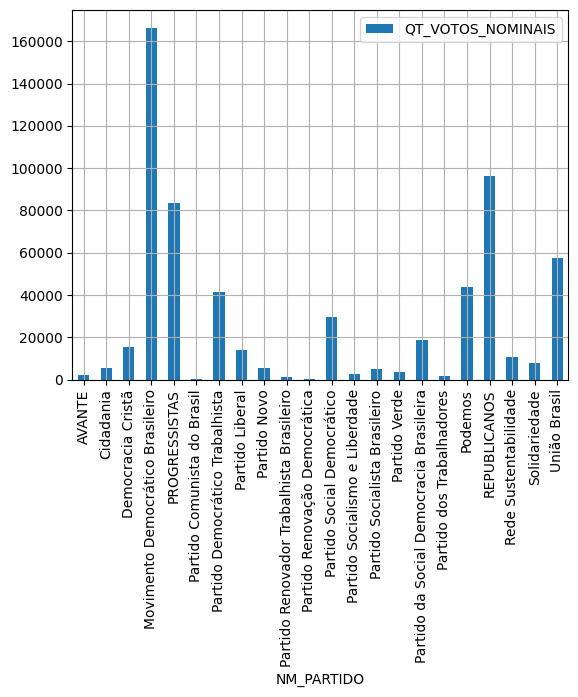

In [39]:
# Gráfico do total de votos por partido

# Faz a cópia do dataframe dados_eleitorais
dados_eleitorais_votos = dados_eleitorais.copy()

# Retira as colunas indesejadas
dados_eleitorais_votos = dados_eleitorais_votos.drop(["NM_MUNICIPIO", "NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO", "CD_CARGO"], axis=1)

# Agrupa pelo nome do partido, somando os valores
dados_eleitorais_votos = dados_eleitorais_votos.groupby(["NM_PARTIDO"]).sum()
display(dados_eleitorais_votos.plot(kind="bar", grid=True))

<Axes: ylabel='NM_MUNICIPIO,CARGO'>

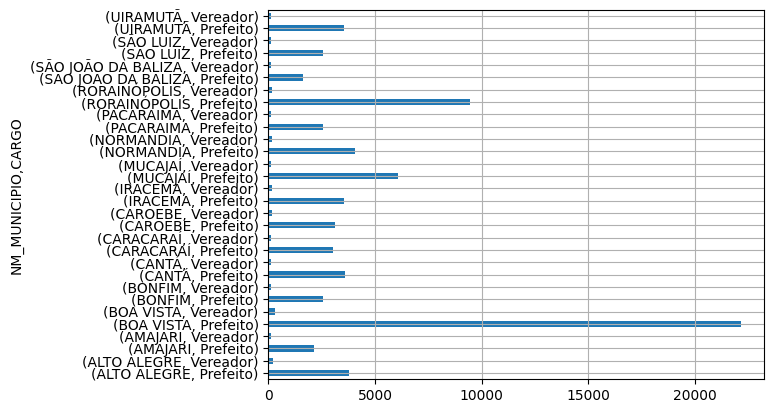

In [52]:
# Gráfico da média de votos por cargo, por município
dados_eleitorais_votos = dados_eleitorais.copy()

# Retira as colunas indesejadas
dados_eleitorais_votos = dados_eleitorais_votos.drop(["NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO", "NM_PARTIDO"], axis=1)

# Aqui, troca faz a troca dos códigos de cargo pelos títulos de cada cargo
dados_eleitorais_votos.loc[dados_eleitorais_votos["CD_CARGO"].isin([13]), "CARGO"] = "Vereador"
dados_eleitorais_votos.loc[dados_eleitorais_votos["CD_CARGO"].isin([11]), "CARGO"] = "Prefeito"

# Agrupa pela cidade e pelo código de cargo, somando os valores
dados_eleitorais_votos = dados_eleitorais_votos["QT_VOTOS_NOMINAIS"].groupby([dados_eleitorais_votos['NM_MUNICIPIO'], dados_eleitorais_votos['CARGO']]).mean()
display(dados_eleitorais_votos.plot(kind="barh", grid=True))

<Axes: ylabel='Frequency'>

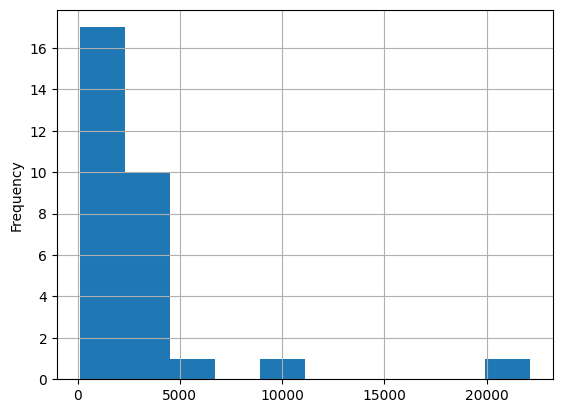

In [53]:
# Mesma ideia do último, mas com um histograma no lugar
display(dados_eleitorais_votos.plot(kind="hist", grid=True))